In [1]:
import numpy as np
from scipy import signal
from scipy.fft import fft, fftfreq, irfft, dct, idct
import cv2
import os
import json
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

import sig_analize as san
import generate_areas as ga
import sequence_image_anal_function as siaf
%load_ext autoreload
%autoreload 2

In [2]:
dir_path = ['./data/drop-211025-2', './data/drop-211025-3', './data/drop-211025-4', './data/drop-211025-5']

img_path_list = siaf.get_imgs_paths(dir_path)
img_path_list

[['./data/drop-211025-2/drop-0050.jpg',
  './data/drop-211025-2/drop-0060.jpg',
  './data/drop-211025-2/drop-0070.jpg',
  './data/drop-211025-2/drop-0080.jpg',
  './data/drop-211025-2/drop-0090.jpg',
  './data/drop-211025-2/drop-0100.jpg',
  './data/drop-211025-2/drop-0110.jpg',
  './data/drop-211025-2/drop-0120.jpg',
  './data/drop-211025-2/drop-0130.jpg',
  './data/drop-211025-2/drop-0140.jpg',
  './data/drop-211025-2/drop-0150.jpg',
  './data/drop-211025-2/drop-0160.jpg',
  './data/drop-211025-2/drop-0170.jpg',
  './data/drop-211025-2/drop-0180.jpg'],
 ['./data/drop-211025-3/drop-050.jpg',
  './data/drop-211025-3/drop-060.jpg',
  './data/drop-211025-3/drop-070.jpg',
  './data/drop-211025-3/drop-080.jpg',
  './data/drop-211025-3/drop-090.jpg',
  './data/drop-211025-3/drop-100.jpg',
  './data/drop-211025-3/drop-110.jpg',
  './data/drop-211025-3/drop-120.jpg',
  './data/drop-211025-3/drop-130.jpg',
  './data/drop-211025-3/drop-140.jpg',
  './data/drop-211025-3/drop-150.jpg',
  './data/

In [3]:
jasons_dir = 'jasons_dir/'
siaf.create_many_jsons(jasons_dir, img_path_list)

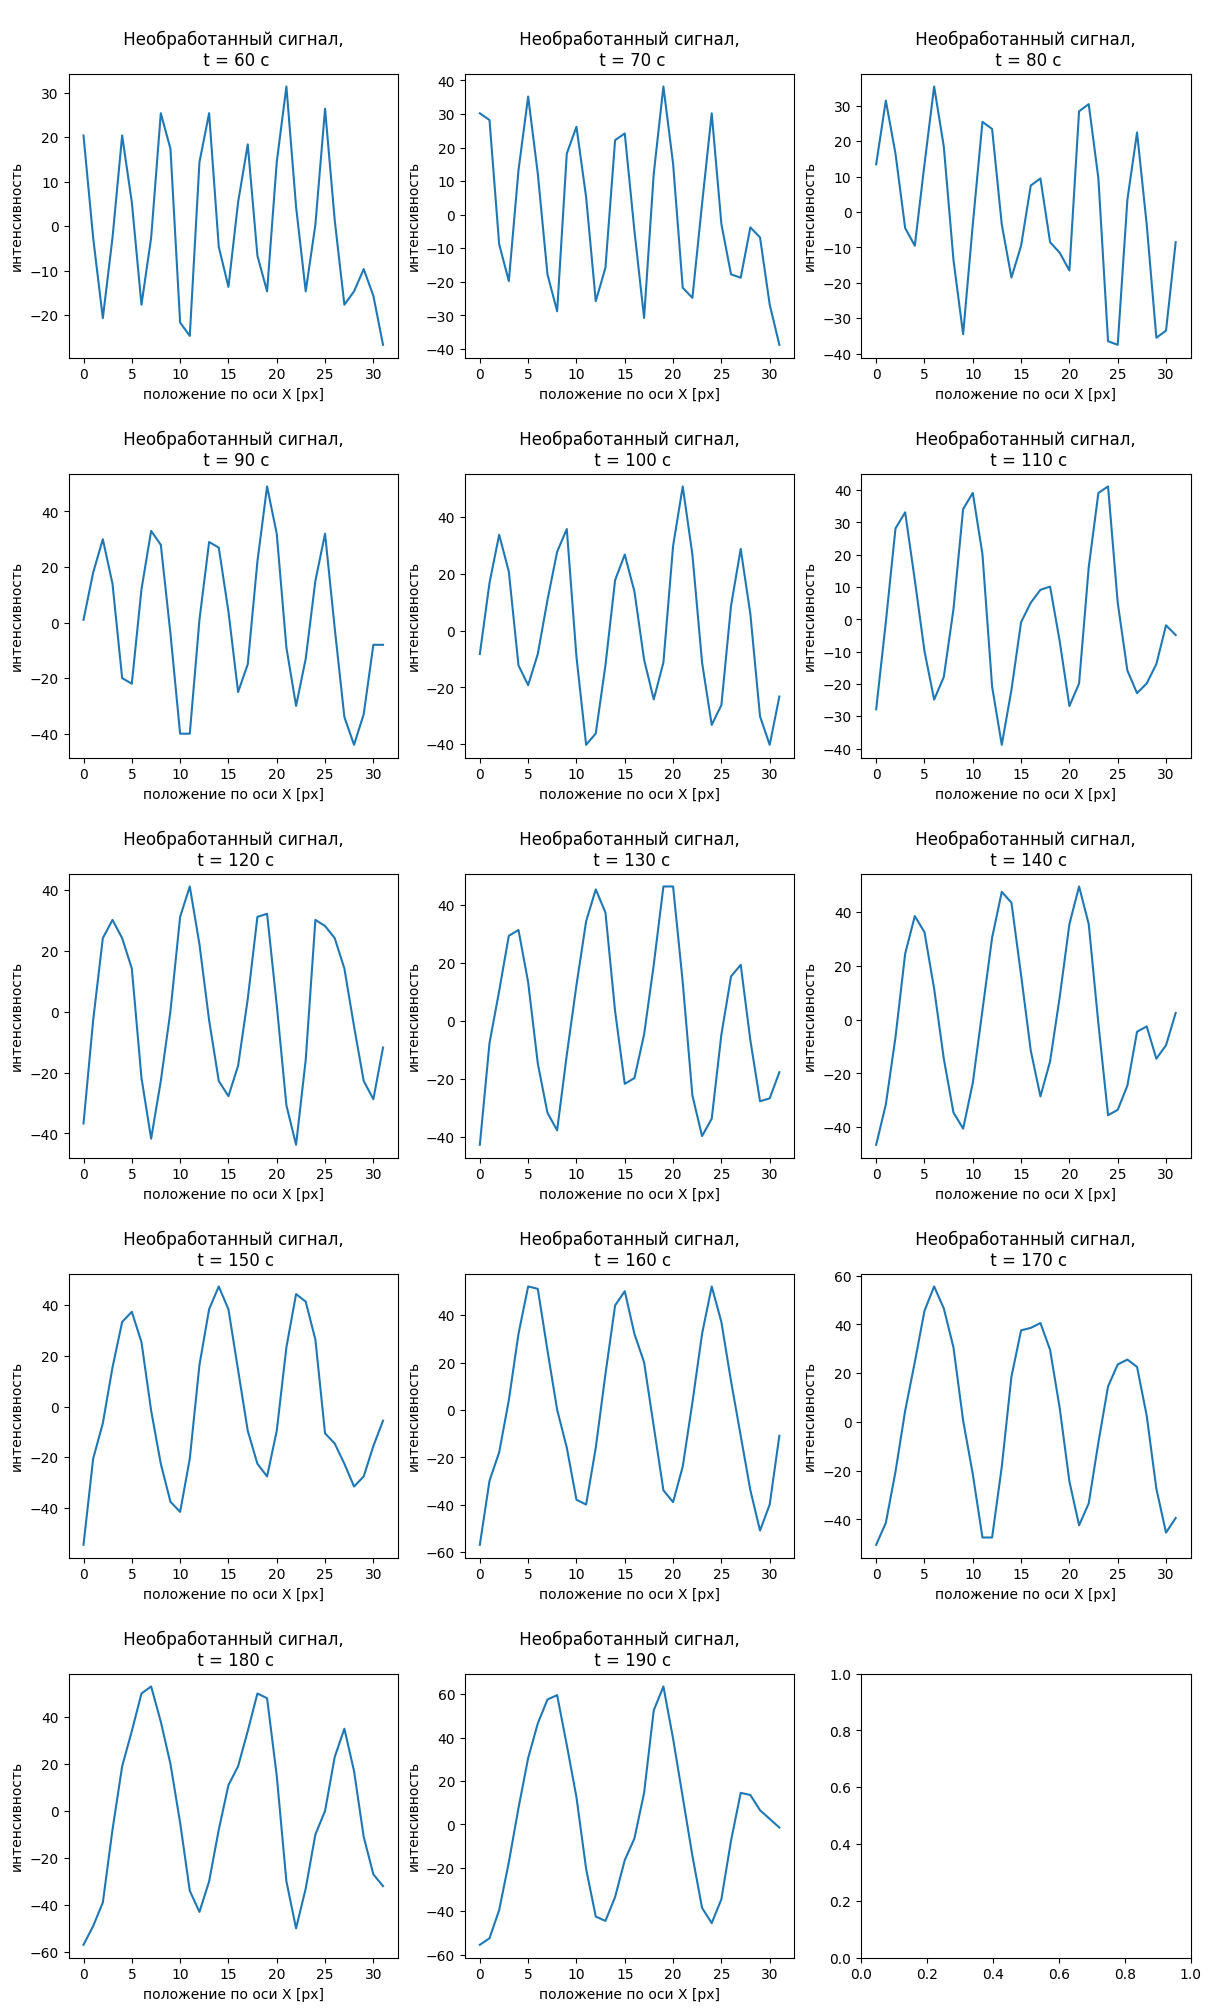

In [34]:
# upload ntencity distributions from json file and
# look at the integral intencity distribution plotted
jasons_dir = 'jasons_dir/'
json_path = jasons_dir+'sequence-3.txt'


imgs = siaf.load_imgs_from_json(json_path)


In [7]:
#fs = 1
#nperseg_c = 1

#sig = imgs[0]
#sig_len = len(sig)

#N = sig_len
#T = 1/fs

#yf = np.fft.fft(sig)
#xf = np.fft.fftfreq(N, T)

#plt.figure(figsize=(3,4))
#plt.plot(xf[:N//2], 2.0/N*np.abs(yf[:N//2]))
#plt.axvline(3/N, color='g', ymin=0, ymax=25, linestyle='--')
#plt.axvline(fs/3, color='g', ymin=0, ymax=25, linestyle='--')
#plt.title('Спектр сигнала')
#plt.xlabel('частота [1/px]')
#plt.ylabel('интенсивность гармоники')
#plt.show()

In [8]:
#sig_len = len(imgs[0])

#fs=1
#nl = 5
#f_min = nl/sig_len
#f_max = 0.3
#border = 4

#bh, ah = signal.butter(border, f_min, btype = 'highpass', fs=fs)
#sig_min = [signal.filtfilt(bh, ah, img, method='gust') for img in imgs]
#bh, ah = signal.butter(border, f_max, btype = 'lowpass', fs=fs)
#sig_max = [signal.filtfilt(bh, ah, sig, method='gust') for sig in sig_min]

#img_count = len(imgs)
#row_count = (img_count+2)//3

#plt.figure()
#fig, ax = plt.subplots(row_count, 3, layout='constrained', figsize=(12, 4*row_count), sharex=False, sharey=False)

#for i in range(img_count):
#    ax[i//3][i%3].plot(sig_max[i])
#    ax[i//3][i%3].set_title(f"\n Обработанный сигнал,\n t = {(i+6)*10} c")
#    ax[i//3][i%3].set_xlabel("положение по оси X [px]")
#    ax[i//3][i%3].set_ylabel("интенсивность")

phase = []
phase_line = []
x = np.arange(len(sig))

for sig in sig_max[::2]:
    sig_anal = signal.hilbert(np.real(sig))
    instant_phase = np.unwrap(np.angle(sig_anal))
    instant_phase = instant_phase - instant_phase[0]
    phase.append(instant_phase)

    slope, intercept = np.polyfit(x, instant_phase, 1)
    phase_line.append(x*slope + intercept)


prop_cycle = plt.rcParams['axes.prop_cycle']
color = prop_cycle.by_key()['color']

plt.figure()
plt.title(f"\n Мгновенная фаза сигнала от расстояния поперек полос")

for i in range(len(phase)):
    plt.plot(phase[i],'+', color = color[i])
    plt.plot(phase_line[i],'--', color = color[i])
    
    ax[i//3][i%3].set_xlabel("положение по оси X [px]")
    ax[i//3][i%3].set_ylabel("фаза")

plt.legend()
plt.show()

In [35]:
fs=1   # frequency of discretization of the signal
nl = 2 # number of lowerest frequencies filtered
sig_len = len(imgs[0]) # we chose areas of the same length from all pictures

sig_h = siaf.filter_low_frq(imgs, nl)

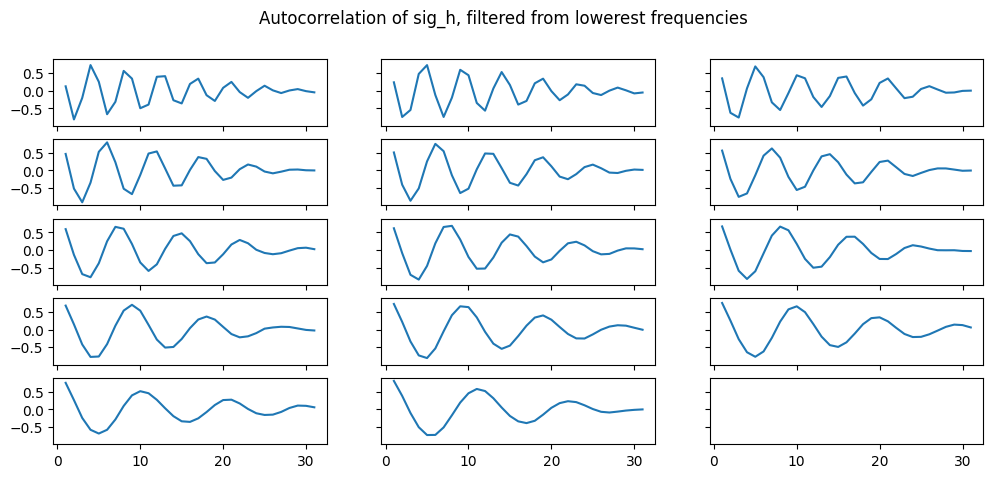

[7, 6, 5, 5, 5, 4, 4, 4, 4, 3, 3, 3, 3, 2]


In [36]:
peak_count = siaf.count_peaks_of_autocorr(sig_h, show_corr = True)
print(peak_count)

In [37]:
# to make peaks more prominent it is nesessary to
# remove low frequencies from the signals
# we will use san.my_butter_high to create high pass filter
# !!! here we use nl = number of peaks in autocorrelation function

fs = 1
border = 4

nl = [pc-1 for pc in peak_count]
sig_hn = siaf.filter_lowest_n_frq(sig_h, nl, show_corr=False, show_flt_sig=False)


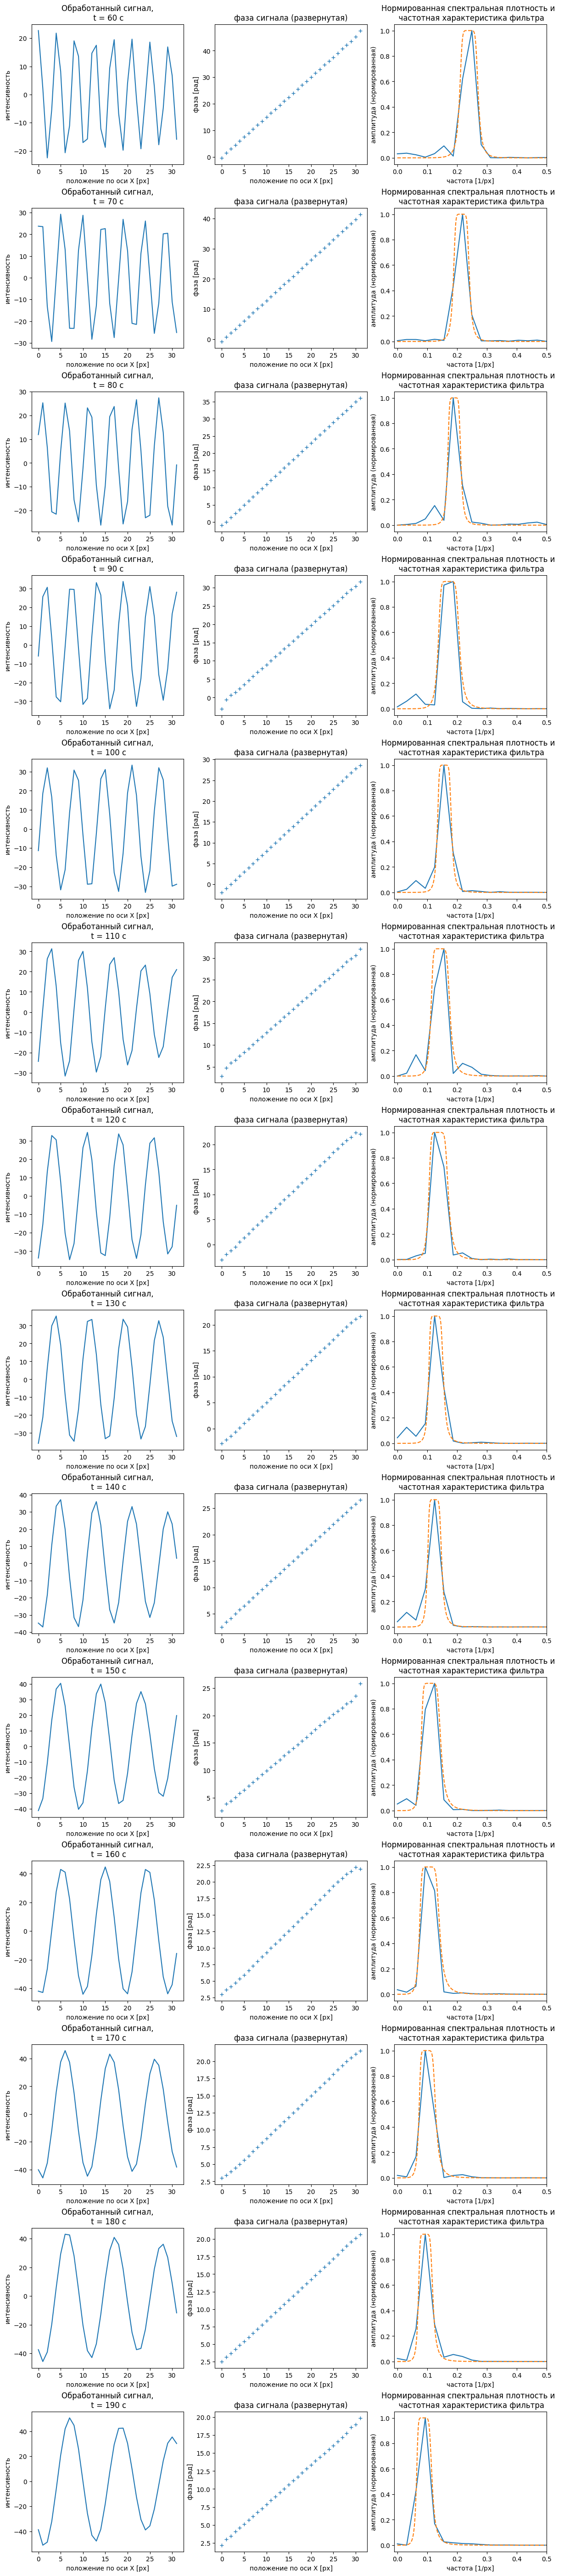

In [38]:
ph_vel_hn, phase = san.plot_flt_res(imgs, fs=1, rel_h=0.5, nperseg_c=1)

plt.rcdefaults()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
default_colors

plt.rcParams['figure.dpi'] = 300
marker=['o', 's', '^','*']

legend_lbs = ['t = 60 c','t = 180 c','t = 300 c','t = 420 c']

plt.figure()
plt.title("Мгновенная фаза сигнала \n от расстояния поперек полос")

phase_i = phase[::4]
x = np.arange(len(phase_i[0]))
for i in range(len(phase_i)):
    plt.scatter(x, phase_i[i] - phase_i[i][0], marker = marker[i])
    

plt.xlabel("положение по оси X [px]")
plt.ylabel("фаза [рад]")
plt.legend(labels=legend_lbs)
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

0.002871959830195882


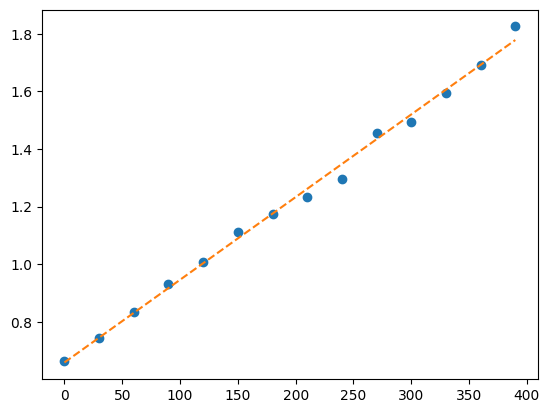

In [39]:
file_name = 'raw_result_dir/sequence_5.txt'
delta_t = 3*10

siaf.write_inv_phase(file_name, ph_vel_hn, delta_t)

Мы получили графики зависимости обратной скорости изменения фазы вдоль направления 
растекания капли от времени (момента, когда кадр был запечетлен), они описываются прямыми.
$$\frac{1}{\frac{d\phi}{dx_{px}}} = t*A + В$$, А - коэффициент пропорциональности
Трение вычисляется по формуле
$$\tau = \frac{dx}{dh}\mu\frac{1}{t}$$
$$\frac{1}{\frac{dh}{dx}} = \frac{\tau}{\mu}t$$
Зависимость фазы от высоты пленки:
$$h=\frac{\lambda}{4\pi}\phi\frac{1}{n_{oil}^2-n_{air}^2\sin{\psi}}$$

Где $\psi$ - угол падения луча (у нас - угол наклона камеры); $\psi = 5град = 0.087 рад$  
$n_{oil} = 1.4, n_{air} = 1$  
$\lambda = 443 nm = 443*10^{-9} m$   
$\nu = 1000 sSt = 10^{-3} m^2/s$ - кинематическая вязкость  
$\mu = \nu \rho = 0.97 кг/(м*с)- динамическая вязкость;    \rho = 971  kg/m^3$  при 20 градусах цельсия
$$\frac{1}{\frac{d\phi}{dx}} = t\tau A_1$$
где $A_1 = \frac{\lambda}{4\pi\mu (n_{oil}^2-n_{air}^2\sin{\psi})} \approx 18.55 * 10^{-9}$
Значение наклона прямой, полученное интерполяцией неоюходимо разделить на 18.55 * 10^{-9},
чтобы получить $\tau$


X  до этого момента выражалась в пикселях, 
разрешение камеры примерно 27800 пиксель/м.
То есть реальные коэффициент наклона прямой можно получить, если коэффициент, полученный из интерполяции, умножить
на 27800.

$dx_{px} = dx*K$  
$\tau = \frac{A}{A_1 K}$  

$$I(x) = A(x)e^{\phi (x)}$$

In [40]:
file_list = ['raw_result_dir/sequence_2.txt','raw_result_dir/sequence_4.txt','raw_result_dir/sequence_3.txt','raw_result_dir/sequence_5.txt']
labels_vel = ['33.1 m/c','37.5 m/c', '43.7 m/c', '48.7 m/c']

[np.float64(2.187063793789787), np.float64(2.619495011893887), np.float64(3.53616128473362), np.float64(4.104015057587645)]


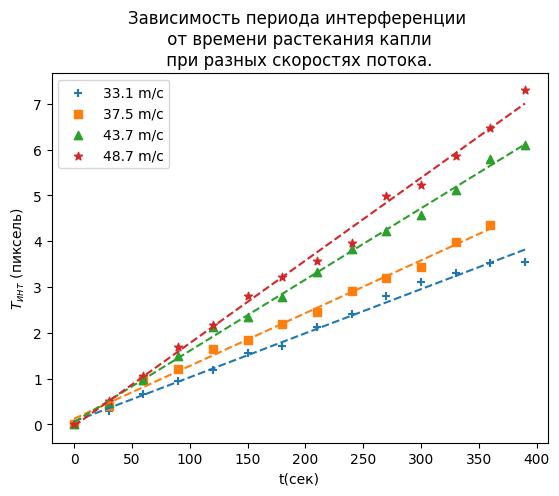

(np.float64(0.0028728937728937733), np.float64(-0.00557142857142852))

In [50]:
fric = siaf.get_friction(file_list, dynamic_visc=1)
print(fric)

siaf.plot_phase_vel(file_list, labels_vel)


[np.float64(2.187063793789787), np.float64(2.619495011893887), np.float64(3.53616128473362), np.float64(4.104015057587645)]
coeffitient of curve_fit_1: 0.004657123536403224
    diviation: [1.14784762]%
coeffitients of curve_fit_2: 0.0063516022296068435, 1.667602815090942
    diviation: [33.19209455  5.28492506]%
coeffitients of Blasius: 0.0056508239105049615, 1.75
 


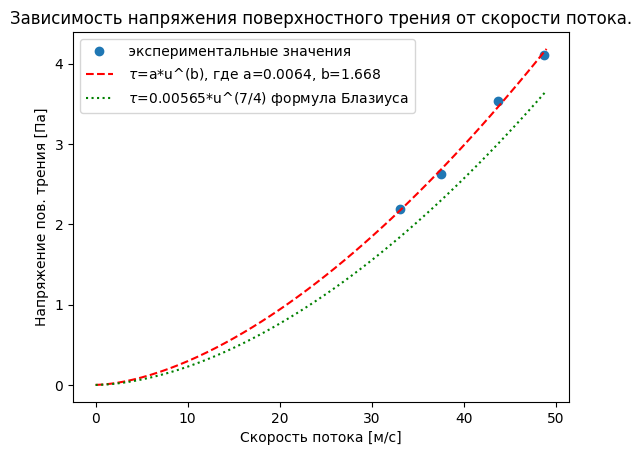

In [49]:
print(fric)

rho_air_20 = 1.2 # kg/m^3 
d_truba = 0.3 # m
nu_kinema_viscos = 1.5*10**(-5) # m^2/c

Koeff = 1.4*0.04*rho_air_20*(nu_kinema_viscos/d_truba)**0.25
Koeff_10 = 0.015*rho_air_20*(2*nu_kinema_viscos/d_truba)**(2/11)
Koeff_lam = 8*rho_air_20*nu_kinema_viscos/d_truba

frq = np.array([33.1,37.5, 43.7, 48.7])

frq_model = np.linspace(0,49,50)
fric_blasius = frq_model**(7/4)*Koeff/1.4
fric_10 = Koeff_10*(frq_model**(20/11))
fric_laminar = frq_model*Koeff_lam

from scipy.optimize import curve_fit

def fit_func_1(x, a):
    return a*x**(7/4)

def fit_func_2(x, a, b):
    return a*x**(b)

popt1, pcov1 = curve_fit(fit_func_1, frq, fric)
print(f"coeffitient of curve_fit_1: {popt1[0]}\n    diviation: {np.sqrt(np.diag(pcov1))/popt1*100}%")
popt2, pcov2 = curve_fit(fit_func_2, frq, fric)
print(f"coeffitients of curve_fit_2: {popt2[0]}, {popt2[1]}\n    diviation: {np.sqrt(np.diag(pcov2))/popt2*100}%")
print(f"coeffitients of Blasius: {Koeff}, {7/4}\n ")

plt.figure()
plt.plot(frq, fric, 'o')
#plt.plot(frq_model, fit_func_1(frq_model, *popt1),'--', color='blue')
plt.plot(frq_model, fit_func_2(frq_model, *popt2),'--', color = 'red')

#plt.plot(frq_model, fric_10, '-')
plt.plot(frq_model, fric_blasius, ':', color='green')
#plt.plot(frq_model, fric_laminar, '--')
plt.legend(labels=[' экспериментальные значения',
                   #fr' $\tau$=a*u^(7/4), где a={popt1[0]:0.4f}',
                  fr' $\tau$=a*u^(b), где a={popt2[0]:0.4f}, b={popt2[1]:0.3f}',
                  r' $\tau$=0.00565*u^(7/4) формула Блазиуса'])
plt.title('Зависимость напряжения поверхностного трения от скорости потока.')
plt.xlabel('Скорость потока [м/с]')
plt.ylabel('Напряжение пов. трения [Па]')
plt.savefig('ScinFric_vs_Vel.png', dpi=150, bbox_inches='tight')
plt.show()